# 🧠 Deep Learning from Scratch / Section 3
# Backpropagation: The Engine of Learning
---
**Builds on:** Sections 1–2  
**Goal:** Derive and implement every gradient by hand using the chain rule.

---
## 📌 Table of Contents
1. [Intuition](#intuition)
2. [The Chain Rule](#chain)
3. [Step-by-Step Gradient Derivation](#derive)
4. [Manual Implementation](#impl)
5. [Gradient Norm Tracking](#norms)
6. [XOR Experiment](#xor)


## 1. Intuition <a id="intuition"></a>

**The core question:** How should we change each weight to reduce the loss?

We need $\frac{\partial L}{\partial W}$ for every weight matrix $W$ in the network. Computing this naively would require a separate forward pass per weight — millions of passes for modern networks.

**Backpropagation** solves this in **one backward pass** by reusing intermediate computations via the chain rule.

Think of it like **blame attribution**:
- The loss is high — *which* weights are responsible?
- Backprop efficiently distributes credit/blame backwards through the network.


## 2. The Chain Rule <a id="chain"></a>

If $L = f(g(x))$, then:
$$\frac{dL}{dx} = \frac{dL}{dg} \cdot \frac{dg}{dx}$$

In a neural network, the loss depends on weights through a **chain of functions**:

$$L \rightarrow \hat{y} \rightarrow Z^{(2)} \rightarrow A^{(1)} \rightarrow Z^{(1)} \rightarrow W^{(1)}$$

Backprop applies the chain rule starting from $L$ and walking backwards.


## 3. Step-by-Step Gradient Derivation <a id="derive"></a>

### Network: 2 → 4 (ReLU) → 1 (Sigmoid), Loss = Binary Cross-Entropy

**Forward pass:**
$$Z^{(1)} = X W^{(1)} + b^{(1)}, \quad A^{(1)} = \text{ReLU}(Z^{(1)})$$
$$Z^{(2)} = A^{(1)} W^{(2)} + b^{(2)}, \quad \hat{y} = \sigma(Z^{(2)})$$
$$L = -\frac{1}{N}\sum_i \left[ y_i \log \hat{y}_i + (1-y_i) \log(1-\hat{y}_i) \right]$$

**Backward pass:**

*Output layer (combined BCE + sigmoid gradient):*
$$\delta^{(2)} = \frac{\partial L}{\partial Z^{(2)}} = \frac{\hat{y} - y}{N}$$

$$\frac{\partial L}{\partial W^{(2)}} = (A^{(1)})^\top \cdot \delta^{(2)}, \quad \frac{\partial L}{\partial b^{(2)}} = \sum \delta^{(2)}$$

*Hidden layer (chain rule through ReLU):*
$$\delta^{(1)} = (\delta^{(2)} \cdot (W^{(2)})^\top) \odot \text{ReLU}'(Z^{(1)})$$

$$\frac{\partial L}{\partial W^{(1)}} = X^\top \cdot \delta^{(1)}, \quad \frac{\partial L}{\partial b^{(1)}} = \sum \delta^{(1)}$$

*Update:*
$$W \leftarrow W - \eta \cdot \frac{\partial L}{\partial W}$$


## 4. Manual Implementation <a id='impl'></a>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#c8ccd8",
    "xtick.color":      "#c8ccd8",
    "ytick.color":      "#c8ccd8",
    "text.color":       "#c8ccd8",
    "grid.color":       "#2a2d3d",
    "grid.alpha":       0.5,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#3a3d4d",
    "font.family":      "monospace",
})

ACCENT = "#7c83ff"
GREEN  = "#56d364"
ORANGE = "#ffa657"
PINK   = "#f778ba"
YELLOW = "#e3b341"

print(" Setup complete — NumPy", np.__version__)


 Setup complete — NumPy 2.0.2


In [10]:


def relu(z):
 
    return np.maximum(0, z)

def relu_derivative(z):
    
    return (z > 0).astype(float)

def sigmoid(z):
   
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

def sigmoid_derivative(z):
    
    s = sigmoid(z)
    return s * (1 - s)

def softmax(z):
  
    z_s   = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_s)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)




In [11]:
class TwoLayerNet:
    """
    2-layer network: 2 → 4 (ReLU) → 1 (Sigmoid)
    Loss: Binary Cross-Entropy
    Every gradient written out explicitly — no abstraction.
    """

    def __init__(self, lr=0.5, n_epochs=5000):
        # Xavier initialisation (good for sigmoid)
        self.W1 = np.random.randn(2, 4) * 0.5
        self.b1 = np.zeros((1, 4))
        self.W2 = np.random.randn(4, 1) * 0.5
        self.b2 = np.zeros((1, 1))
        self.lr = lr
        self.n_epochs = n_epochs
        self.loss_hist = []
        self.grad_norms_W1 = []
        self.grad_norms_W2 = []

    # ── Forward ───────────────────────────────────────────────────────────────
    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1    # pre-activation layer 1
        self.A1 = relu(self.Z1)             # activation layer 1
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = sigmoid(self.Z2)          # final prediction ŷ
        return self.A2

    def bce_loss(self, y_pred, y_true):
        eps = 1e-12
        return -np.mean(y_true * np.log(y_pred + eps) +
                        (1 - y_true) * np.log(1 - y_pred + eps))

    # ── Backward ──────────────────────────────────────────────────────────────
    def backward(self, X, y_true):
        n = X.shape[0]

        # ── Layer 2 gradients ─────────────────────────────────────────────────
        # Combined BCE + sigmoid: dL/dZ2 = (ŷ - y) / N
        dZ2 = (self.A2 - y_true) / n         # (n, 1)
        dW2 = self.A1.T @ dZ2                 # (4, 1)  ← dL/dW2
        db2 = dZ2.sum(axis=0, keepdims=True)  # (1, 1)

        # ── Layer 1 gradients ─────────────────────────────────────────────────
        # Backprop through W2:   dL/dA1 = dZ2 @ W2ᵀ
        dA1 = dZ2 @ self.W2.T                      # (n, 4)
        # Backprop through ReLU: dL/dZ1 = dL/dA1 ⊙ ReLU'(Z1)
        dZ1 = dA1 * relu_derivative(self.Z1)       # (n, 4)
        dW1 = X.T @ dZ1                            # (2, 4)  ← dL/dW1
        db1 = dZ1.sum(axis=0, keepdims=True)       # (1, 4)

        self.grads = dict(dW1=dW1, db1=db1, dW2=dW2, db2=db2)

    def update(self):
        self.W1 -= self.lr * self.grads["dW1"]
        self.b1 -= self.lr * self.grads["db1"]
        self.W2 -= self.lr * self.grads["dW2"]
        self.b2 -= self.lr * self.grads["db2"]

    def fit(self, X, y):
        for epoch in range(self.n_epochs):
            y_pred = self.forward(X)
            self.loss_hist.append(self.bce_loss(y_pred, y))
            self.backward(X, y)
            self.grad_norms_W1.append(np.linalg.norm(self.grads["dW1"]))
            self.grad_norms_W2.append(np.linalg.norm(self.grads["dW2"]))
            self.update()
        return self

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int).ravel()

print(" TwoLayerNet with manual backprop defined")


 TwoLayerNet with manual backprop defined


## 6. XOR Experiment <a id="xor"></a>

XOR is the canonical test for non-linear classifiers:

| $x_1$ | $x_2$ | $y = x_1 \oplus x_2$ |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

A single perceptron **cannot** solve this. Our 2-layer net with a hidden ReLU layer can.


In [12]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float).reshape(-1, 1)

net = TwoLayerNet(lr=0.5, n_epochs=5000)
net.fit(X_xor, y_xor)

print("  XOR predictions after training:")
for xi, yi, yp in zip(X_xor, y_xor.ravel(), net.predict(X_xor)):
    status = "✓" if int(yi) == yp else "✗"
    print(f"    {status}  input={xi.astype(int)}  true={int(yi)}  pred={yp}")


  XOR predictions after training:
    ✗  input=[0 0]  true=0  pred=1
    ✓  input=[0 1]  true=1  pred=1
    ✓  input=[1 0]  true=1  pred=1
    ✓  input=[1 1]  true=0  pred=0


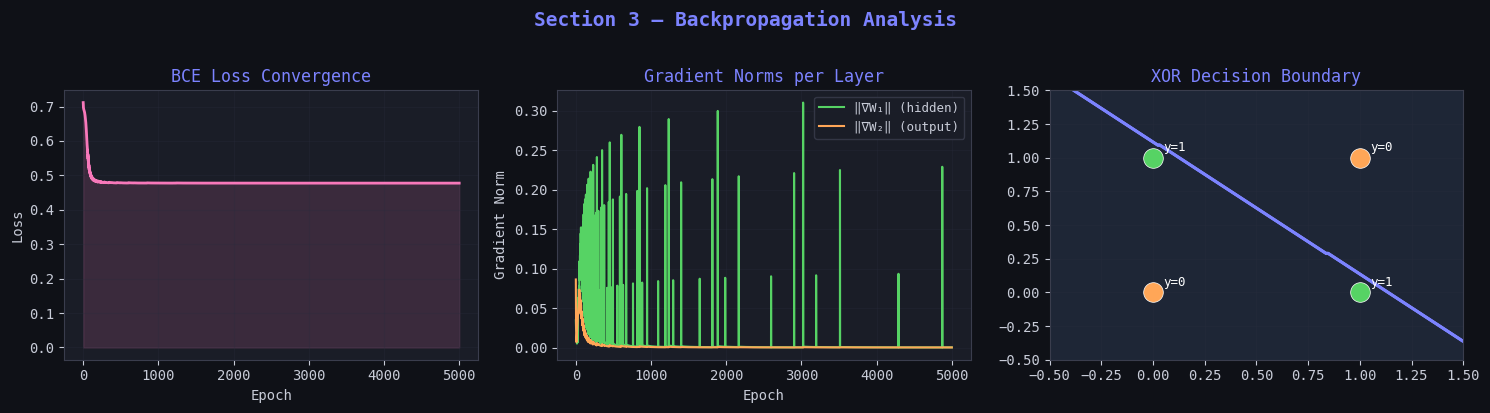

In [13]:
# visuals
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Section 3 — Backpropagation Analysis", fontsize=14,
             color=ACCENT, fontweight="bold", y=1.02)

# Loss
ax = axes[0]
ax.set_facecolor("#1a1d27")
ax.set_title("BCE Loss Convergence", color=ACCENT)
ax.plot(net.loss_hist, color=PINK, lw=2)
ax.fill_between(range(len(net.loss_hist)), net.loss_hist, alpha=0.15, color=PINK)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.grid(True, alpha=0.3)

# Gradient norms — early layers often have smaller gradients (vanishing problem)
ax2 = axes[1]
ax2.set_facecolor("#1a1d27")
ax2.set_title("Gradient Norms per Layer", color=ACCENT)
ax2.plot(net.grad_norms_W1, color=GREEN,  lw=1.5, label="‖∇W₁‖ (hidden)")
ax2.plot(net.grad_norms_W2, color=ORANGE, lw=1.5, label="‖∇W₂‖ (output)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Gradient Norm")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# XOR decision boundary
ax3 = axes[2]
ax3.set_facecolor("#1a1d27")
ax3.set_title("XOR Decision Boundary", color=ACCENT)
xr = np.linspace(-0.5, 1.5, 200)
xx_x, yy_x = np.meshgrid(xr, xr)
Z_x = (net.forward(np.c_[xx_x.ravel(), yy_x.ravel()]) >= 0.5).astype(int).reshape(xx_x.shape)
ax3.contourf(xx_x, yy_x, Z_x, alpha=0.3, colors=["#2a3d5a","#3d2a5a"])
ax3.contour(xx_x, yy_x, Z_x, colors=[ACCENT], linewidths=1.5)
for xi, yi in zip(X_xor, y_xor.ravel()):
    col = GREEN if yi == 1 else ORANGE
    ax3.scatter(*xi, c=col, s=200, zorder=5, edgecolors="white", linewidths=0.5)
    ax3.text(xi[0]+0.05, xi[1]+0.05, f"y={int(yi)}", color="white", fontsize=9)
ax3.set_xlim(-0.5, 1.5); ax3.set_ylim(-0.5, 1.5)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 🔑 Key Takeaways

| Concept | Detail |
|---|---|
| **Chain rule** | Core math behind backprop — reuse intermediate results |
| **δ (delta)** | Error signal propagated backwards through layers |
| **Gradient norms** | Measure how much each layer is "learning" |
| **Vanishing gradients** | Early layers can have tiny gradients in deep nets |
| **ReLU advantage** | Constant gradient for positive $z$ — alleviates vanishing |

➡️ **Next:** Section 4 introduces **Convolutional Neural Networks** — spatial feature detectors for image data.
